# Mean Variance Portfolio

In [81]:
from pathlib import Path

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

CURRENT_DIRECTORY = Path.cwd()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "etf_adjusted_close.csv"
)

RESULTS_DIRECTORY = (
    PROJECT_ROOT / "results"
)

gmv_weights_history = pd.read_csv(
    RESULTS_DIRECTORY
    / "gmv_weights_history.csv",
    index_col="Date",
    parse_dates=["Date"],
)

gmv_returns = pd.read_csv(
    RESULTS_DIRECTORY
    / "gmv_daily_returns.csv",
    index_col="Date",
    parse_dates=["Date"],
).squeeze("columns")

TRADING_DAYS = 252
ESTIMATION_YEARS = 3

RISK_AVERSION_VALUES = [
    1,
    2,
    5,
    10,
    20,
    50,
    100,
]

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Data exists:", DATA_PATH.exists())

Project root: /Users/yyi/Projects/Portfolio optimization
Data path: /Users/yyi/Projects/Portfolio optimization/data/processed/etf_adjusted_close.csv
Data exists: True


In [82]:
prices = pd.read_csv(
    DATA_PATH,
    index_col="Date",
    parse_dates=["Date"],
)

prices = prices.sort_index()

returns = (
    prices
    .pct_change(fill_method=None)
    .dropna()
)

print(
    "Full return data:",
    returns.index.min(),
    "to",
    returns.index.max(),
)

print("Returns shape:", returns.shape)

Full return data: 2007-04-12 00:00:00 to 2020-04-01 00:00:00
Returns shape: (3267, 12)


In [83]:
backtest_start = returns.index[
    returns.index
    >= returns.index.min()
    + pd.DateOffset(years=ESTIMATION_YEARS)
][0]

backtest_end = returns.index.max()

backtest_returns = returns.loc[
    backtest_start:backtest_end
]

formation_dates = (
    backtest_returns
    .groupby(
        backtest_returns.index.to_period("M")
    )
    .head(1)
    .index
)

print("Backtest start:", backtest_start)
print("Backtest end:", backtest_end)
print("Number of formation dates:", len(formation_dates))
print("First formation dates:", formation_dates[:5])

Backtest start: 2010-04-12 00:00:00
Backtest end: 2020-04-01 00:00:00
Number of formation dates: 121
First formation dates: DatetimeIndex(['2010-04-12', '2010-05-03', '2010-06-01', '2010-07-01',
               '2010-08-02'],
              dtype='datetime64[us]', name='Date', freq=None)


In [84]:
comparison_formation_date = (
    formation_dates[0]
)

comparison_estimation_start = (
    comparison_formation_date
    - pd.DateOffset(
        years=ESTIMATION_YEARS
    )
)

comparison_estimation_returns = returns.loc[
    (
        returns.index
        >= comparison_estimation_start
    )
    & (
        returns.index
        < comparison_formation_date
    )
]

print(
    "Comparison formation date:",
    comparison_formation_date,
)

print(
    "Estimation period:",
    comparison_estimation_returns.index.min(),
    "to",
    comparison_estimation_returns.index.max(),
)

print(
    "Number of estimation observations:",
    len(comparison_estimation_returns),
)

Comparison formation date: 2010-04-12 00:00:00
Estimation period: 2007-04-12 00:00:00 to 2010-04-09 00:00:00
Number of estimation observations: 755


In [85]:
def solve_mean_variance(
    estimation_returns,
    risk_aversion,
):
    asset_names = estimation_returns.columns
    number_of_assets = len(asset_names)

    annualized_expected_returns = (
        estimation_returns.mean().values
        * TRADING_DAYS
    )

    annualized_covariance_matrix = (
        estimation_returns.cov().values
        * TRADING_DAYS
    )

    weight = cp.Variable(
        number_of_assets,
        name="weight",
    )

    expected_portfolio_return = (
        annualized_expected_returns @ weight
    )

    portfolio_variance = cp.quad_form(
        weight,
        annualized_covariance_matrix,
    )

    objective = cp.Maximize(
        expected_portfolio_return
        - risk_aversion * portfolio_variance
    )

    constraints = [
        cp.sum(weight) == 1,
        weight >= 0,
    ]

    problem = cp.Problem(
        objective,
        constraints,
    )

    problem.solve(solver="CLARABEL")

    if problem.status not in [
        "optimal",
        "optimal_inaccurate",
    ]:
        raise ValueError(
            f"Optimization failed: {problem.status}"
        )

    optimized_weights = pd.Series(
        weight.value,
        index=asset_names,
        name="mean_variance_weight",
    )

    optimized_weights = optimized_weights.clip(lower=0)
    optimized_weights /= optimized_weights.sum()

    return optimized_weights

In [86]:
risk_aversion_values = [
    0.1,
    1,
    10,
    100
]

mean_variance_weights = pd.DataFrame({
    gamma: solve_mean_variance(
        comparison_estimation_returns,
        risk_aversion=gamma,
    )
    for gamma in risk_aversion_values
})

mean_variance_weights.columns.name = (
    "Risk Aversion"
)

mean_variance_weights.round(4)

for gamma in risk_aversion_values:
    print(f"\nRisk aversion = {gamma}")

    print(
        mean_variance_weights[gamma]
        .sort_values(ascending=False)
        .head(3)
        .round(4)
    )

gmv_comparison_weights = (
    gmv_weights_history.loc[
        comparison_formation_date
    ]
)

print(f"\nminimum_variance")
print(
    gmv_comparison_weights.sort_values(ascending=False).head(3).round(4)
)


Risk aversion = 0.1
GLD    1.0
EEM    0.0
VNQ    0.0
Name: 0.1, dtype: float64

Risk aversion = 1
GLD    0.9153
EEM    0.0847
IEF    0.0000
Name: 1.0, dtype: float64

Risk aversion = 10
IEF    0.6677
GLD    0.1599
QQQ    0.0896
Name: 10.0, dtype: float64

Risk aversion = 100
IEF    0.7318
QQQ    0.0958
HYG    0.0840
Name: 100.0, dtype: float64

minimum_variance
IEF    0.7428
QQQ    0.0838
HYG    0.0811
Name: 2010-04-12 00:00:00, dtype: float64


In [87]:
annualized_mean = (
    comparison_estimation_returns.mean()
    * TRADING_DAYS
)

annualized_covariance = (
    comparison_estimation_returns.cov()
    * TRADING_DAYS
)

weight_comparison = pd.DataFrame({
    "GMV": gmv_comparison_weights,
    "MV_gamma_100": mean_variance_weights[100],
})

comparison_statistics = {}

for portfolio_name in weight_comparison.columns:

    current_weights = (
        weight_comparison[portfolio_name]
        .values
    )

    estimated_return = (
        annualized_mean.values
        @ current_weights
    )

    estimated_variance = (
        current_weights
        @ annualized_covariance.values
        @ current_weights
    )

    comparison_statistics[portfolio_name] = {
        "Estimated Return": estimated_return,
        "Estimated Variance": estimated_variance,
        "Estimated Volatility": np.sqrt(
            estimated_variance
        ),
    }

pd.DataFrame(comparison_statistics).T

,Estimated Return,Estimated Variance,Estimated Volatility
GMV,0.073239,0.004076,0.063844
MV_gamma_100,0.076345,0.004091,0.063964


In [88]:
mean_variance_weights_history = {}

for risk_aversion in RISK_AVERSION_VALUES:

    current_weights_history = pd.DataFrame(
        index=formation_dates,
        columns=returns.columns,
        dtype=float,
    )

    for formation_date in formation_dates:

        estimation_start = (
            formation_date
            - pd.DateOffset(
                years=ESTIMATION_YEARS
            )
        )

        current_estimation_returns = returns.loc[
            (returns.index >= estimation_start)
            & (returns.index < formation_date)
        ]

        optimized_weights = solve_mean_variance(
            current_estimation_returns,
            risk_aversion=risk_aversion,
        )

        current_weights_history.loc[
            formation_date
        ] = optimized_weights

    mean_variance_weights_history[
        risk_aversion
    ] = current_weights_history

In [89]:
for (
    risk_aversion,
    current_weights_history,
) in mean_variance_weights_history.items():

    print(
        f"Gamma = {risk_aversion}"
    )

    print(
        "Shape:",
        current_weights_history.shape,
    )

    print(
        "Missing values:",
        current_weights_history
        .isna()
        .sum()
        .sum(),
    )

    print(
        "Weight-sum range:",
        current_weights_history
        .sum(axis=1)
        .min(),
        "to",
        current_weights_history
        .sum(axis=1)
        .max(),
    )

    print()

Gamma = 1
Shape: (121, 12)
Missing values: 0
Weight-sum range: 0.9999999999999998 to 1.0000000000000002

Gamma = 2
Shape: (121, 12)
Missing values: 0
Weight-sum range: 0.9999999999999997 to 1.0000000000000002

Gamma = 5
Shape: (121, 12)
Missing values: 0
Weight-sum range: 0.9999999999999997 to 1.0000000000000002

Gamma = 10
Shape: (121, 12)
Missing values: 0
Weight-sum range: 0.9999999999999998 to 1.0000000000000002

Gamma = 20
Shape: (121, 12)
Missing values: 0
Weight-sum range: 0.9999999999999998 to 1.0000000000000002

Gamma = 50
Shape: (121, 12)
Missing values: 0
Weight-sum range: 0.9999999999999998 to 1.0000000000000002

Gamma = 100
Shape: (121, 12)
Missing values: 0
Weight-sum range: 0.9999999999999998 to 1.0000000000000004



In [90]:
for risk_aversion in RISK_AVERSION_VALUES:

    print(
        f"\nGamma = {risk_aversion}"
    )

    print(
        mean_variance_weights_history[
            risk_aversion
        ]
        .iloc[0]
        .sort_values(ascending=False)
        .head(4)
        .round(4)
    )


Gamma = 1
GLD    0.9153
EEM    0.0847
IEF    0.0000
TLT    0.0000
Name: 2010-04-12 00:00:00, dtype: float64

Gamma = 2
GLD    0.5516
IEF    0.3587
EEM    0.0897
LQD    0.0000
Name: 2010-04-12 00:00:00, dtype: float64

Gamma = 5
IEF    0.6363
GLD    0.2505
EEM    0.0614
QQQ    0.0317
Name: 2010-04-12 00:00:00, dtype: float64

Gamma = 10
IEF    0.6677
GLD    0.1599
QQQ    0.0896
HYG    0.0630
Name: 2010-04-12 00:00:00, dtype: float64

Gamma = 20
IEF    0.6934
GLD    0.1112
QQQ    0.1050
HYG    0.0812
Name: 2010-04-12 00:00:00, dtype: float64

Gamma = 50
IEF    0.7206
QQQ    0.1014
HYG    0.0853
GLD    0.0715
Name: 2010-04-12 00:00:00, dtype: float64

Gamma = 100
IEF    0.7318
QQQ    0.0958
HYG    0.0840
GLD    0.0547
Name: 2010-04-12 00:00:00, dtype: float64


In [91]:
def backtest_monthly_weights(
    returns,
    weights_history,
    backtest_end,
):
    """
    Backtest monthly target weights without rebalancing within each month.
    """
    formation_dates = weights_history.index
    realized_return_segments = []

    for i, formation_date in enumerate(
        formation_dates
    ):
        initial_weights = (
            weights_history
            .loc[formation_date]
            .astype(float)
        )

        if i < len(formation_dates) - 1:
            next_formation_date = (
                formation_dates[i + 1]
            )

            holding_returns = returns.loc[
                (returns.index >= formation_date)
                & (
                    returns.index
                    < next_formation_date
                )
            ]

        else:
            holding_returns = returns.loc[
                (returns.index >= formation_date)
                & (returns.index <= backtest_end)
            ]

        # Asset growth during the holding month.
        asset_growth = (
            1 + holding_returns
        ).cumprod()

        # Portfolio wealth, starting from one dollar.
        portfolio_wealth = (
            asset_growth
            .mul(
                initial_weights,
                axis="columns",
            )
            .sum(axis=1)
        )

        # Daily realized portfolio returns.
        portfolio_returns = (
            portfolio_wealth.pct_change()
        )

        portfolio_returns.iloc[0] = (
            portfolio_wealth.iloc[0] - 1
        )

        realized_return_segments.append(
            portfolio_returns
        )

    realized_returns = pd.concat(
        realized_return_segments
    )

    return realized_returns

In [92]:
mean_variance_returns = {}

for risk_aversion in RISK_AVERSION_VALUES:

    current_returns = backtest_monthly_weights(
        returns=returns,
        weights_history=(
            mean_variance_weights_history[
                risk_aversion
            ]
        ),
        backtest_end=backtest_end,
    )

    current_returns.name = (
        f"MV_gamma_{risk_aversion:g}"
    )

    mean_variance_returns[
        risk_aversion
    ] = current_returns

In [93]:
mean_variance_returns = pd.concat(
    mean_variance_returns.values(),
    axis=1,
)

print(mean_variance_returns.head())
print(mean_variance_returns.tail())

print(
    "Shape:",
    mean_variance_returns.shape,
)

print(
    "Missing values:\n",
    mean_variance_returns.isna().sum(),
)

print(
    "Duplicate dates:",
    mean_variance_returns
    .index
    .duplicated()
    .sum(),
)

print(
    "Matches backtest dates:",
    mean_variance_returns
    .index
    .equals(backtest_returns.index),
)

            MV_gamma_1  MV_gamma_2  MV_gamma_5  MV_gamma_10  MV_gamma_20  \
Date                                                                       
2010-04-12   -0.005751   -0.002808   -0.000134     0.000914     0.001383   
2010-04-13   -0.002767   -0.001056    0.000599     0.001447     0.001797   
2010-04-14    0.004011    0.002002    0.000368     0.000115    -0.000060   
2010-04-15    0.004550    0.003128    0.002297     0.002504     0.002474   
2010-04-16   -0.021888   -0.012130   -0.003788    -0.001315    -0.000077   

            MV_gamma_50  MV_gamma_100  
Date                                   
2010-04-12     0.001655      0.001772  
2010-04-13     0.001997      0.002075  
2010-04-14    -0.000113     -0.000066  
2010-04-15     0.002348      0.002294  
2010-04-16     0.000658      0.000905  
            MV_gamma_1  MV_gamma_2  MV_gamma_5  MV_gamma_10  MV_gamma_20  \
Date                                                                       
2020-03-26    0.043417    0.030047 

In [94]:
spy_returns = (
    returns.loc[
        mean_variance_returns.index,
        "SPY",
    ]
    .rename("SPY")
)

comparison_returns = pd.concat(
    [
        gmv_returns.rename("GMV"),
        spy_returns,
        mean_variance_returns,
    ],
    axis=1,
)

print(comparison_returns.head())
print(comparison_returns.tail())
print(comparison_returns.isna().sum())

assert comparison_returns.isna().sum().sum() == 0
assert comparison_returns.index.duplicated().sum() == 0

comparison_wealth = (
    1 + comparison_returns
).cumprod()

                 GMV       SPY  MV_gamma_1  MV_gamma_2  MV_gamma_5  \
Date                                                                 
2010-04-12  0.001915  0.001589   -0.005751   -0.002808   -0.000134   
2010-04-13  0.002136  0.000752   -0.002767   -0.001056    0.000599   
2010-04-14  0.000030  0.011349    0.004011    0.002002    0.000368   
2010-04-15  0.002229  0.000825    0.004550    0.003128    0.002297   
2010-04-16  0.001164 -0.015912   -0.021888   -0.012130   -0.003788   

            MV_gamma_10  MV_gamma_20  MV_gamma_50  MV_gamma_100  
Date                                                             
2010-04-12     0.000914     0.001383     0.001655      0.001772  
2010-04-13     0.001447     0.001797     0.001997      0.002075  
2010-04-14     0.000115    -0.000060    -0.000113     -0.000066  
2010-04-15     0.002504     0.002474     0.002348      0.002294  
2010-04-16    -0.001315    -0.000077     0.000658      0.000905  
                 GMV       SPY  MV_gamma_1  MV_

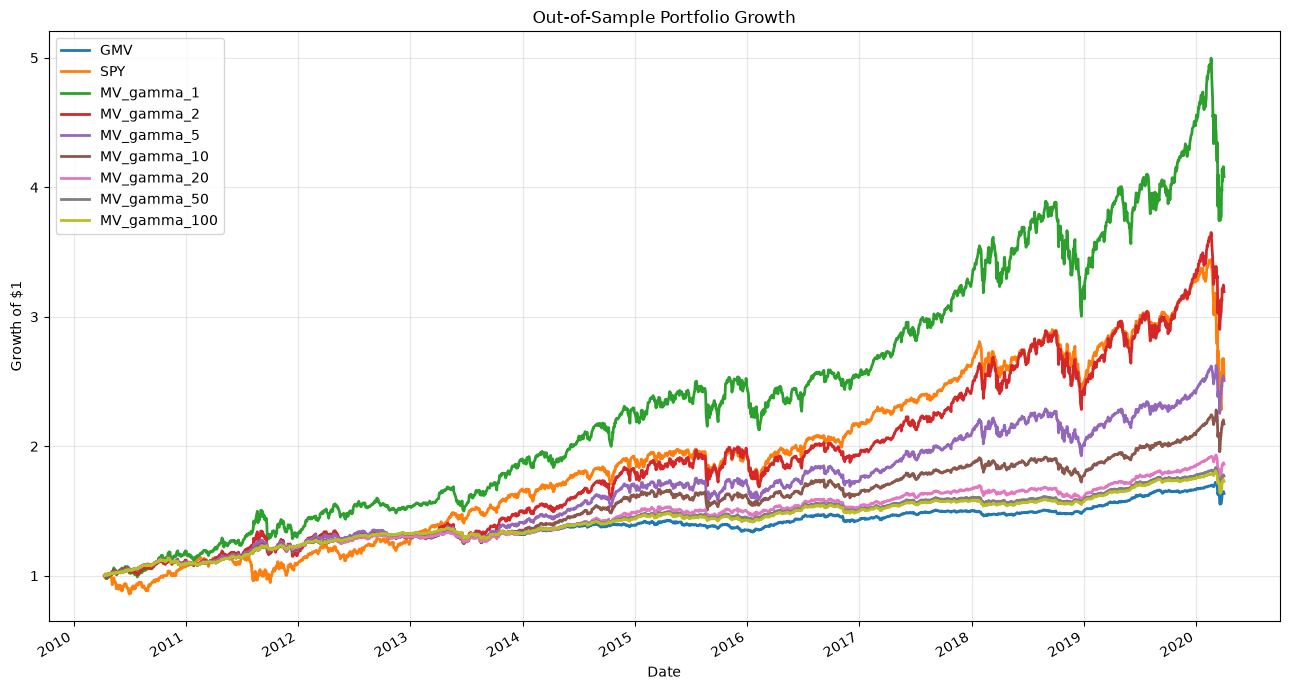

In [95]:
fig, ax = plt.subplots(
    figsize=(13, 7)
)

comparison_wealth.plot(
    ax=ax,
    linewidth=2,
)

ax.set_title(
    "Out-of-Sample Portfolio Growth"
)

ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [96]:
def calculate_performance_metrics(
    portfolio_returns,
    trading_days=252,
):
    wealth = (
        1 + portfolio_returns
    ).cumprod()

    number_of_days = len(
        portfolio_returns
    )

    cagr = (
        wealth.iloc[-1]
        ** (
            trading_days
            / number_of_days
        )
        - 1
    )

    annualized_volatility = (
        portfolio_returns.std()
        * np.sqrt(trading_days)
    )

    sharpe_ratio = (
        portfolio_returns.mean()
        / portfolio_returns.std()
        * np.sqrt(trading_days)
    )

    running_maximum = wealth.cummax()

    drawdown = (
        wealth
        / running_maximum
        - 1
    )

    maximum_drawdown = drawdown.min()

    return pd.Series({
        "Final Wealth": wealth.iloc[-1],
        "CAGR": cagr,
        "Annualized Volatility": (
            annualized_volatility
        ),
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": (
            maximum_drawdown
        ),
    })

In [97]:
performance_comparison = (
    comparison_returns
    .apply(
        calculate_performance_metrics
    )
    .T
)

performance_comparison

,Final Wealth,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
GMV,1.635434,0.050585,0.043291,1.161665,-0.098190
SPY,2.519200,0.097120,0.169469,0.632206,-0.337173
MV_gamma_1,4.083151,0.151580,0.168011,0.924594,-0.251207
MV_gamma_2,3.194037,0.123556,0.146519,0.868764,-0.210107
MV_gamma_5,2.506237,0.096552,0.104023,0.938349,-0.158397
MV_gamma_10,2.172300,0.080934,0.077642,1.041421,-0.141708
MV_gamma_20,1.861747,0.064334,0.054944,1.162412,-0.107252
MV_gamma_50,1.769136,0.058900,0.044472,1.309296,-0.084146
MV_gamma_100,1.728112,0.056411,0.043657,1.278994,-0.094716


In [98]:
formatted_performance = (
    performance_comparison.copy()
)

for column in [
    "CAGR",
    "Annualized Volatility",
    "Maximum Drawdown",
]:
    formatted_performance[column] = (
        formatted_performance[column]
        .map(lambda value: f"{value:.2%}")
    )

formatted_performance[
    "Final Wealth"
] = formatted_performance[
    "Final Wealth"
].map(lambda value: f"{value:.3f}")

formatted_performance[
    "Sharpe Ratio"
] = formatted_performance[
    "Sharpe Ratio"
].map(lambda value: f"{value:.3f}")

formatted_performance

,Final Wealth,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
GMV,1.635,5.06%,4.33%,1.162,-9.82%
SPY,2.519,9.71%,16.95%,0.632,-33.72%
MV_gamma_1,4.083,15.16%,16.80%,0.925,-25.12%
MV_gamma_2,3.194,12.36%,14.65%,0.869,-21.01%
MV_gamma_5,2.506,9.66%,10.40%,0.938,-15.84%
MV_gamma_10,2.172,8.09%,7.76%,1.041,-14.17%
MV_gamma_20,1.862,6.43%,5.49%,1.162,-10.73%
MV_gamma_50,1.769,5.89%,4.45%,1.309,-8.41%
MV_gamma_100,1.728,5.64%,4.37%,1.279,-9.47%


In [99]:
qqq_returns = (
    returns.loc[
        mean_variance_returns.index,
        "QQQ",
    ]
    .rename("QQQ")
)

gld_returns = (
    returns.loc[
        mean_variance_returns.index,
        "GLD",
    ]
    .rename("GLD")
)


comparison_returns = pd.concat(
    [
        gmv_returns.rename("GMV"),
        spy_returns,
        qqq_returns,
        gld_returns,
        mean_variance_returns,
    ],
    axis=1,
)

assert comparison_returns.isna().sum().sum() == 0

In [100]:
comparison_wealth = (
    1 + comparison_returns
).cumprod()

performance_comparison = (
    comparison_returns
    .apply(calculate_performance_metrics)
    .T
)

performance_comparison

,Final Wealth,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
GMV,1.635434,0.050585,0.043291,1.161665,-0.098190
SPY,2.519200,0.097120,0.169469,0.632206,-0.337173
QQQ,4.132945,0.152981,0.191936,0.838231,-0.285594
GLD,1.315118,0.027861,0.157048,0.253715,-0.455550
MV_gamma_1,4.083151,0.151580,0.168011,0.924594,-0.251207
MV_gamma_2,3.194037,0.123556,0.146519,0.868764,-0.210107
MV_gamma_5,2.506237,0.096552,0.104023,0.938349,-0.158397
MV_gamma_10,2.172300,0.080934,0.077642,1.041421,-0.141708
MV_gamma_20,1.861747,0.064334,0.054944,1.162412,-0.107252
MV_gamma_50,1.769136,0.058900,0.044472,1.309296,-0.084146


### Out-of-Sample Performance Comparison

The table compares the realized performance of the rolling mean–variance
strategies with the global minimum-variance portfolio (GMV), SPY, and QQQ over
the common 2010–2020 backtest period.

As the risk-aversion parameter $\gamma$ increases, the mean–variance portfolios
display a clear transition from return-seeking to risk-minimizing allocations.
The annualized volatility decreases from 18.29% for $\gamma=0.1$ to 4.37% for
$\gamma=100$, while CAGR decreases from 15.90% to 5.64%.

The low-risk-aversion strategy, $\gamma=0.1$, achieves the highest final wealth
and CAGR. It slightly outperforms QQQ while exhibiting lower annualized
volatility, although both strategies experience the same maximum drawdown of
approximately 28.56%. This indicates that the strategy was strongly exposed to
QQQ during important market declines, even though its allocations changed over
time.

The $\gamma=1$ strategy produces a CAGR close to that of QQQ but improves its
risk characteristics. Its annualized volatility is 16.80%, compared with 19.19%
for QQQ, and its maximum drawdown is smaller at 25.12%. Consequently, it achieves
a higher Sharpe ratio.

The intermediate strategy, $\gamma=10$, sacrifices some return in exchange for
substantially lower risk. Its CAGR of 8.09% is below SPY's 9.71%, but its
annualized volatility and maximum drawdown are less than half those of SPY.

At the most risk-averse setting, $\gamma=100$, the mean–variance portfolio closely
resembles the GMV portfolio. Nevertheless, it achieves a slightly higher CAGR,
a slightly smaller maximum drawdown, and the highest Sharpe ratio in the
comparison. This suggests that a small exposure to estimated expected returns
improved realized performance during this particular sample without materially
increasing volatility.

Overall, the results demonstrate the economic role of $\gamma$: lower values
favor estimated return and produce more aggressive portfolios, whereas higher
values increasingly prioritize variance reduction. There is no universally
optimal value of $\gamma$ because the appropriate choice depends on the
investor's risk preferences.

These results should not be interpreted as evidence that one value of $\gamma$
is generally superior. Selecting $\gamma$ after observing the full backtest
would introduce data-snooping bias. In addition, the backtest excludes
transaction costs, assumes a zero risk-free rate when calculating Sharpe ratios,
and covers a period in which U.S. technology equities performed particularly
well.

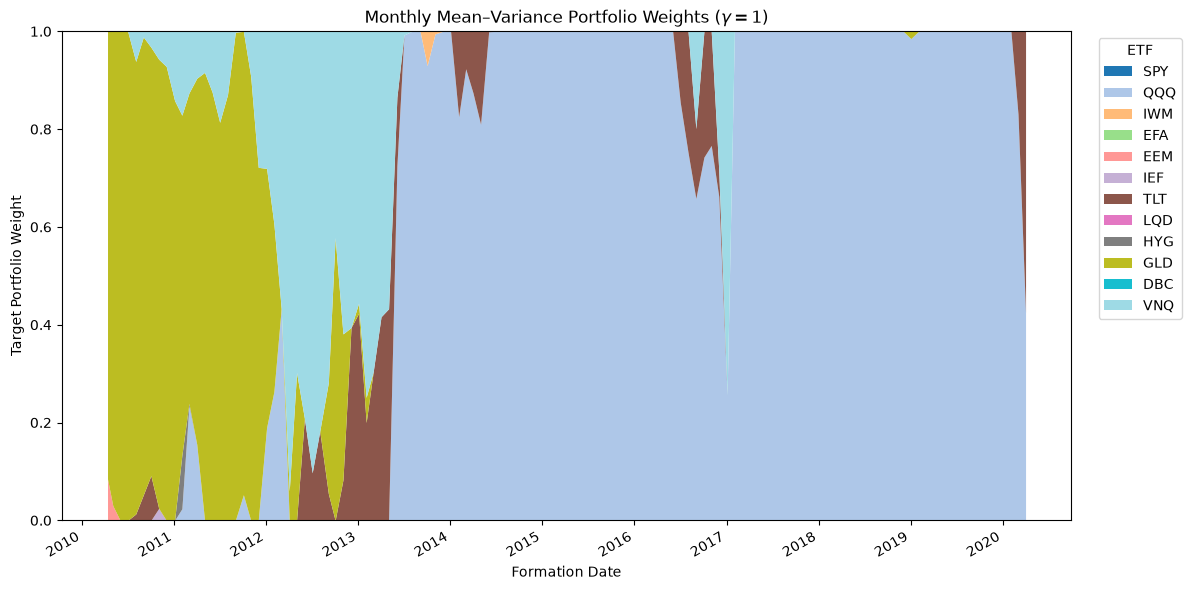

In [101]:
gamma_to_plot = 1

weight_history = (
    mean_variance_weights_history[gamma_to_plot]
    .astype(float)
)

ax = weight_history.plot.area(
    figsize=(12, 6),
    stacked=True,
    linewidth=0,
    colormap="tab20",
)

ax.set_title(
    f"Monthly Mean–Variance Portfolio Weights ($\\gamma={gamma_to_plot}$)"
)
ax.set_xlabel("Formation Date")
ax.set_ylabel("Target Portfolio Weight")
ax.set_ylim(0, 1)

ax.legend(
    title="ETF",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

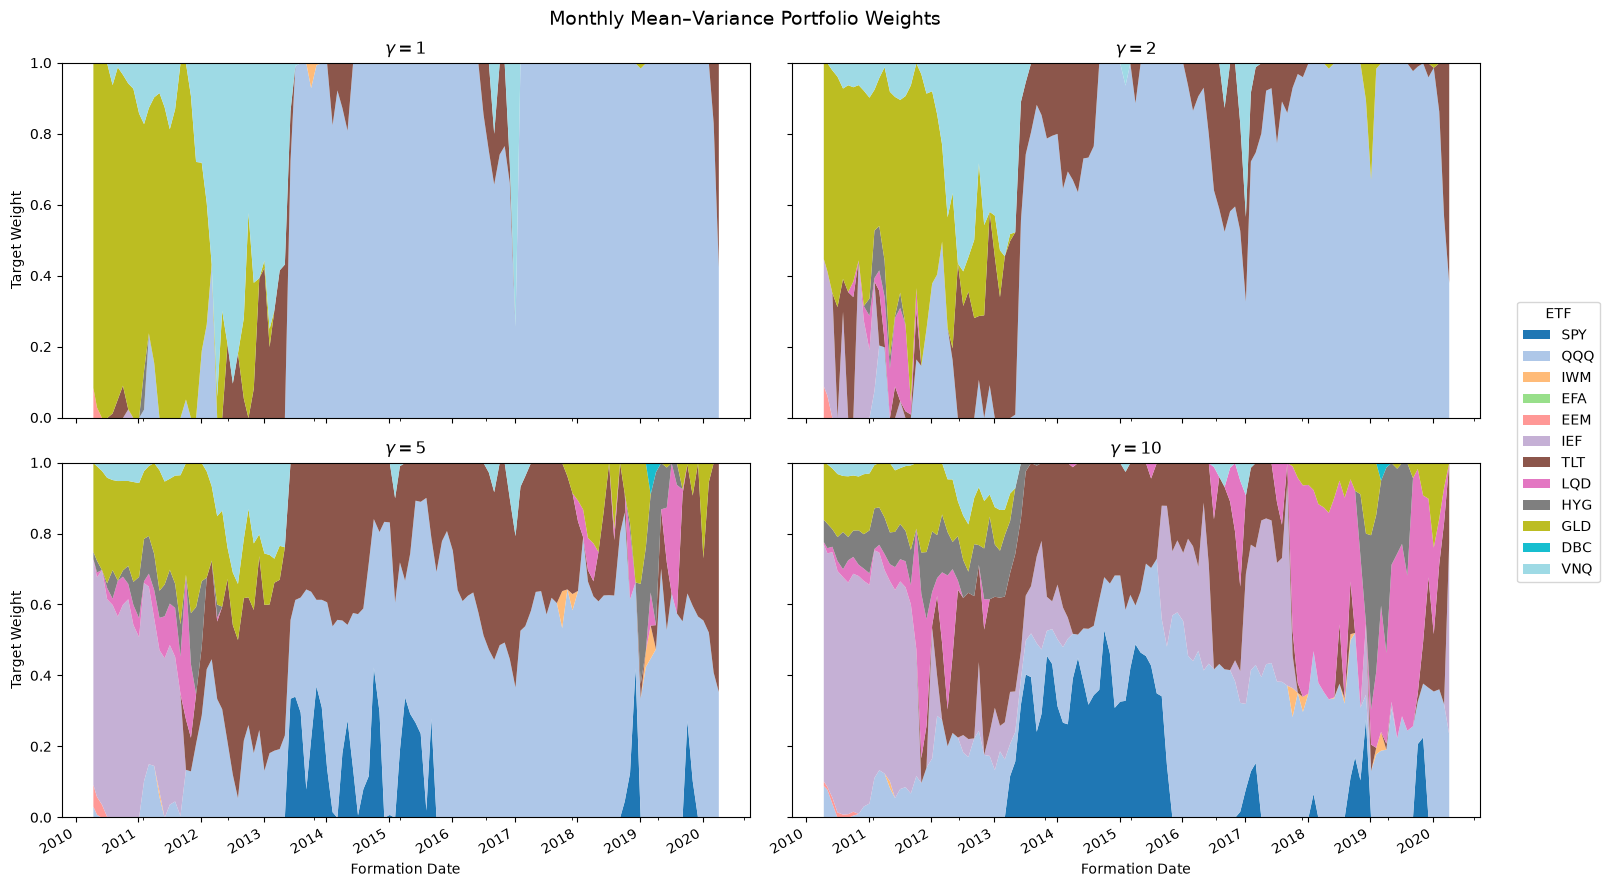

In [102]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 9),
    sharex=True,
    sharey=True,
)

for gamma, ax in zip(
    RISK_AVERSION_VALUES,
    axes.flatten(),
):
    weight_history = (
        mean_variance_weights_history[gamma]
        .astype(float)
    )

    weight_history.plot.area(
        ax=ax,
        stacked=True,
        linewidth=0,
        colormap="tab20",
        legend=False,
    )

    ax.set_title(f"$\\gamma={gamma}$")
    ax.set_xlabel("Formation Date")
    ax.set_ylabel("Target Weight")
    ax.set_ylim(0, 1)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="ETF",
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
)

fig.suptitle(
    "Monthly Mean–Variance Portfolio Weights",
    fontsize=14,
)

plt.tight_layout()
plt.show()

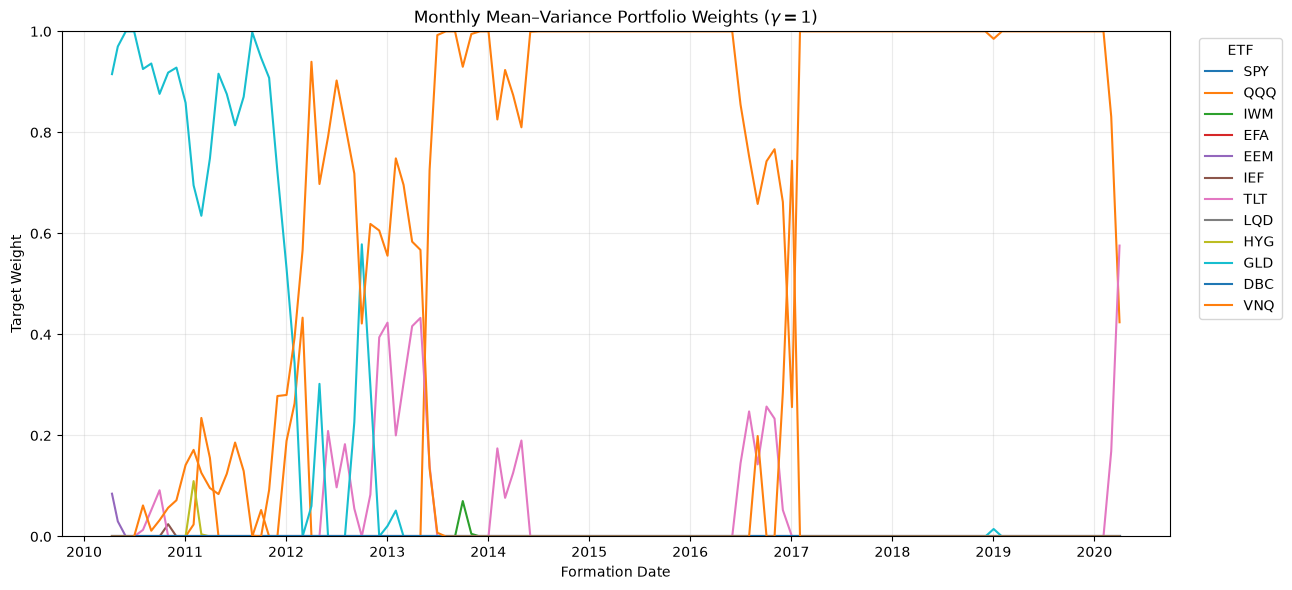

In [103]:
gamma_to_plot = 1

weight_history = (
    mean_variance_weights_history[gamma_to_plot]
    .astype(float)
)

fig, ax = plt.subplots(figsize=(13, 6))

for asset in weight_history.columns:
    ax.plot(
        weight_history.index,
        weight_history[asset],
        label=asset,
        linewidth=1.5,
    )

ax.set_title(
    f"Monthly Mean–Variance Portfolio Weights ($\\gamma={gamma_to_plot}$)"
)
ax.set_xlabel("Formation Date")
ax.set_ylabel("Target Weight")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)

ax.legend(
    title="ETF",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

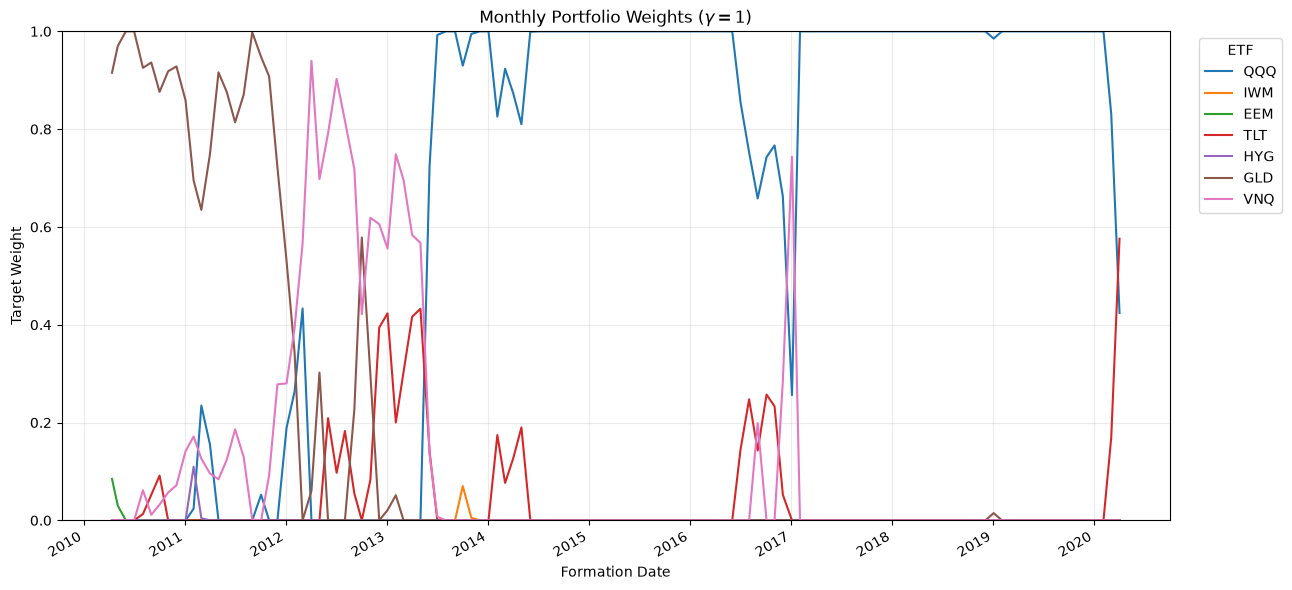

In [104]:
meaningful_assets = weight_history.columns[
    weight_history.max() >= 0.05
]

weight_history[meaningful_assets].plot(
    figsize=(13, 6),
    linewidth=1.5,
)

plt.title(
    f"Monthly Portfolio Weights ($\\gamma={gamma_to_plot}$)"
)
plt.xlabel("Formation Date")
plt.ylabel("Target Weight")
plt.ylim(0, 1)
plt.grid(alpha=0.25)

plt.legend(
    title="ETF",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

### Portfolio Weight Dynamics

The figure displays the target portfolio weights selected at each monthly
formation date. Because the expected-return vector and covariance matrix are
re-estimated using a rolling three-year window, the optimized allocation changes
throughout the backtest.

The portfolios with low risk aversion are highly concentrated. For
$\gamma=0.1$, the optimizer frequently allocates nearly the entire portfolio to
a single ETF, rotating from GLD to VNQ and eventually to QQQ. The
$\gamma=1$ strategy is also dominated by QQQ during much of the later backtest
period. This helps explain why these strategies produced performance similar to
QQQ.

The $\gamma=10$ portfolio is more diversified, but its allocations remain
unstable and change substantially across formation dates. At $\gamma=100$, the
variance penalty dominates the estimated-return term, resulting in a more stable
allocation concentrated primarily in IEF and HYG.

These results illustrate an important weakness of sample mean–variance
optimization. Historical mean returns are noisy, and a low variance penalty
allows the optimizer to amplify small differences in estimated returns into
extreme portfolio allocations. Increasing $\gamma$ reduces this sensitivity and
produces more persistent weights.

In [105]:
turnover_summary = {}

for gamma, weight_history in mean_variance_weights_history.items():
    weight_history = weight_history.astype(float)

    monthly_turnover = (
        weight_history
        .diff()
        .abs()
        .sum(axis=1)
        / 2
    ).dropna()

    turnover_summary[gamma] = {
        "Average Monthly Turnover": monthly_turnover.mean(),
        "Median Monthly Turnover": monthly_turnover.median(),
        "Maximum Monthly Turnover": monthly_turnover.max(),
    }

turnover_summary = (
    pd.DataFrame(turnover_summary)
    .T
)

turnover_summary.index.name = "Gamma"
turnover_summary

,Average Monthly Turnover,Median Monthly Turnover,Maximum Monthly Turnover
Gamma,,,
1,0.080810,0.000002,0.743867
2,0.108681,0.062986,0.601129
5,0.142167,0.123883,0.574385
10,0.154000,0.121708,0.568961
20,0.135798,0.108994,0.511719
50,0.053971,0.042273,0.254824
100,0.028244,0.018495,0.272121


In [106]:
turnover_summary.style.format({
    "Average Monthly Turnover": "{:.2%}",
    "Median Monthly Turnover": "{:.2%}",
    "Maximum Monthly Turnover": "{:.2%}",
})

,Average Monthly Turnover,Median Monthly Turnover,Maximum Monthly Turnover
Gamma,,,
1,8.08%,0.00%,74.39%
2,10.87%,6.30%,60.11%
5,14.22%,12.39%,57.44%
10,15.40%,12.17%,56.90%
20,13.58%,10.90%,51.17%
50,5.40%,4.23%,25.48%
100,2.82%,1.85%,27.21%


In [107]:
all_weight_histories = {
    "GMV": gmv_weights_history,
    **{
        f"MV_gamma_{gamma}": weight_history
        for gamma, weight_history
        in mean_variance_weights_history.items()
    },
}

concentration_results = []

for strategy, weight_history in all_weight_histories.items():
    weight_history = weight_history.astype(float)

    # Largest ETF weight in each month
    maximum_weight = weight_history.max(axis=1)

    # HHI in each month
    hhi = weight_history.pow(2).sum(axis=1)

    # Equivalent number of equally weighted assets
    effective_number_of_assets = 1 / hhi

    # Number of ETFs with economically meaningful weights
    active_assets = (
        weight_history > 0.01
    ).sum(axis=1)

    concentration_results.append({
        "Strategy": strategy,
        "Average Maximum Weight": maximum_weight.mean(),
        "Months Above 90%": (
            maximum_weight > 0.90
        ).mean(),
        "Average HHI": hhi.mean(),
        "Effective Number of Assets":
            effective_number_of_assets.mean(),
        "Average Active Assets": active_assets.mean(),
    })

concentration_table = (
    pd.DataFrame(concentration_results)
    .set_index("Strategy")
)

concentration_table

,Average Maximum Weight,Months Above 90%,Average HHI,Effective Number of Assets,Average Active Assets
Strategy,,,,,
GMV,0.618029,0.000000,0.472126,2.140169,4.578512
MV_gamma_1,0.904284,0.694215,0.862835,1.240472,1.561983
MV_gamma_2,0.772179,0.388430,0.699577,1.648160,2.247934
MV_gamma_5,0.536112,0.000000,0.429050,2.484757,3.404959
MV_gamma_10,0.458235,0.000000,0.346897,3.066337,4.347107
MV_gamma_20,0.525593,0.000000,0.378352,2.840348,4.933884
MV_gamma_50,0.602893,0.000000,0.439961,2.325538,4.504132
MV_gamma_100,0.616984,0.000000,0.464072,2.180482,4.322314


In [108]:
concentration_table.style.format({
    "Average Maximum Weight": "{:.2%}",
    "Months Above 90%": "{:.2%}",
    "Average HHI": "{:.3f}",
    "Effective Number of Assets": "{:.2f}",
    "Average Active Assets": "{:.2f}",
})

,Average Maximum Weight,Months Above 90%,Average HHI,Effective Number of Assets,Average Active Assets
Strategy,,,,,
GMV,61.80%,0.00%,0.472,2.14,4.58
MV_gamma_1,90.43%,69.42%,0.863,1.24,1.56
MV_gamma_2,77.22%,38.84%,0.700,1.65,2.25
MV_gamma_5,53.61%,0.00%,0.429,2.48,3.40
MV_gamma_10,45.82%,0.00%,0.347,3.07,4.35
MV_gamma_20,52.56%,0.00%,0.378,2.84,4.93
MV_gamma_50,60.29%,0.00%,0.440,2.33,4.50
MV_gamma_100,61.70%,0.00%,0.464,2.18,4.32


### Portfolio Concentration

Portfolio concentration is evaluated using the average maximum asset weight,
the Herfindahl–Hirschman Index (HHI), the effective number of assets, and the
number of assets with weights above 1%.

The low-risk-aversion portfolios are extremely concentrated. For
$\gamma=0.1$, the largest position has an average weight of 99.03%, and more
than 90% of the portfolio is allocated to one ETF in 96.69% of formation
periods. Its effective number of assets is only 1.02. The $\gamma=1$ strategy
is somewhat less extreme but remains highly concentrated.

The $\gamma=10$ portfolio is the most diversified among the examined
mean–variance strategies. Its largest position averages 45.82%, and its
effective number of assets is 3.07. However, this diversification is accompanied
by the highest average monthly turnover.

At $\gamma=100$, the portfolio approaches the risk-focused behavior of GMV.
Their concentration statistics are similar, with effective asset counts of
2.18 and 2.14, respectively.

Overall, $\gamma=10$ provides the strongest diversification in this experiment,
but no single value of $\gamma$ should be selected solely from performance over
the full backtest period. Doing so would use out-of-sample results for parameter
selection and introduce data-snooping bias.

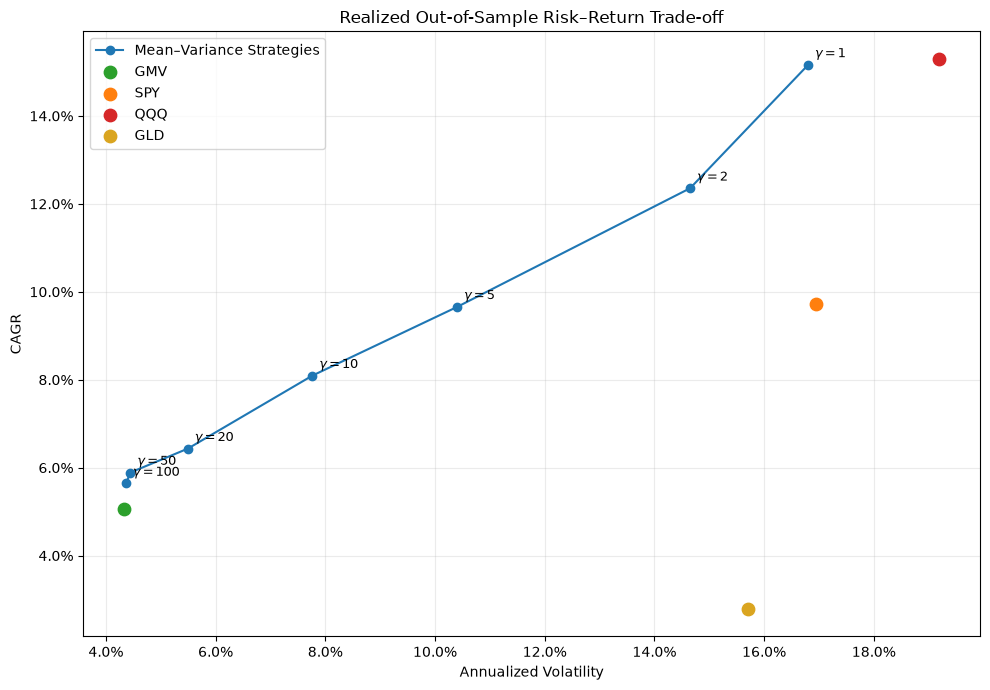

In [111]:
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(10, 7))

mv_strategies = [
    strategy
    for strategy in performance_comparison.index
    if strategy.startswith("MV_gamma_")
]

# Mean-variance strategies
ax.plot(
    performance_comparison.loc[
        mv_strategies,
        "Annualized Volatility",
    ],
    performance_comparison.loc[
        mv_strategies,
        "CAGR",
    ],
    marker="o",
    linewidth=1.5,
    color="tab:blue",
    label="Mean–Variance Strategies",
)

for strategy in mv_strategies:
    gamma = strategy.replace("MV_gamma_", "")

    ax.annotate(
        rf"$\gamma={gamma}$",
        (
            performance_comparison.loc[
                strategy,
                "Annualized Volatility",
            ],
            performance_comparison.loc[
                strategy,
                "CAGR",
            ],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

# Benchmarks
benchmark_colors = {
    "GMV": "tab:green",
    "SPY": "tab:orange",
    "QQQ": "tab:red",
    "GLD": "goldenrod",
}

for benchmark, color in benchmark_colors.items():
    ax.scatter(
        performance_comparison.loc[
            benchmark,
            "Annualized Volatility",
        ],
        performance_comparison.loc[
            benchmark,
            "CAGR",
        ],
        s=80,
        color=color,
        label=benchmark,
        zorder=3,
    )

ax.set_title(
    "Realized Out-of-Sample Risk–Return Trade-off"
)
ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("CAGR")

ax.xaxis.set_major_formatter(
    PercentFormatter(1.0)
)
ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Realized Risk–Return Trade-off

The mean–variance strategies form a clear realized risk–return relationship.
As $\gamma$ increases, the portfolios move toward the lower-left region of the
figure, reflecting lower realized growth and lower volatility.

The $\gamma=1$ strategy achieves a CAGR close to QQQ while exhibiting lower
volatility. Similarly, $\gamma=5$ produces a CAGR close to SPY with substantially
lower volatility. At higher levels of risk aversion, $\gamma=50$ achieves a
higher CAGR than GMV with only a small increase in volatility.

Among the examined parameters, $\gamma=50$ produces the highest realized Sharpe
ratio. However, this does not establish it as the universally optimal parameter,
because the comparison uses the same 2010–2020 backtest period to evaluate all
candidate values.

This figure represents realized out-of-sample results rather than a classical
estimated efficient frontier.

In [113]:
TRANSACTION_COST = 0.01  # 10 basis points per unit of turnover

net_performance_results = []

for strategy, weight_history in all_weight_histories.items():
    gross_returns = comparison_returns[strategy].copy()

    target_turnover = (
        weight_history
        .astype(float)
        .diff()
        .abs()
        .sum(axis=1)
        / 2
    ).dropna()

    rebalance_dates = gross_returns.index.intersection(
        target_turnover.index
    )

    net_returns = gross_returns.copy()

    net_returns.loc[rebalance_dates] = (
        (1 + net_returns.loc[rebalance_dates])
        * (
            1
            - TRANSACTION_COST
            * target_turnover.loc[rebalance_dates]
        )
        - 1
    )

    metrics = calculate_performance_metrics(net_returns)
    metrics["Strategy"] = strategy

    net_performance_results.append(metrics)

net_performance_table = (
    pd.DataFrame(net_performance_results)
    .set_index("Strategy")
)

display(
    net_performance_table.style.format({
        "Final Wealth": "{:.3f}",
        "CAGR": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}",
    })
)

,Final Wealth,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Strategy,,,,,
GMV,1.632,5.04%,4.33%,1.156,-9.82%
MV_gamma_1,4.043,15.05%,16.80%,0.919,-25.13%
MV_gamma_2,3.152,12.21%,14.65%,0.860,-21.02%
MV_gamma_5,2.463,9.47%,10.40%,0.922,-15.94%
MV_gamma_10,2.132,7.89%,7.76%,1.017,-14.17%
MV_gamma_20,1.831,6.26%,5.50%,1.132,-10.73%
MV_gamma_50,1.758,5.82%,4.45%,1.294,-8.41%
MV_gamma_100,1.722,5.60%,4.37%,1.271,-9.47%
